<h1>06_qubit_demos with Remote Qick</h1>


This notebook is inspired by `06_qubit_demos`. You can find the code on their <a href="https://github.com/openquantumhardware/qick/blob/main/qick_demos/06_qubit_demos.ipynb">github page</a>. It is similar to the 06 qubit qualibration.ipynb script but is designed to allow the pulses for the JPA pump to be generated directly on the QICK board.

**Connnection to the serveur**

In [1]:
from tqdm import tqdm
from matplotlib.pyplot import *
from numpy import *

In [2]:
from QickRemote import QickClient 
from QickRemote import QickJob 
client = QickClient(ip_server="localhost", port=5555)

In [3]:
from qick import *
soccfg = client.get_config()
print(soccfg)

QICK running on ZCU216, software version 0.2.286

Firmware configuration (built Mon Aug 21 11:09:34 2023):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MH

C:\Users\NS2-manip\AppData\Local\miniforge3\envs\new_qick\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Helper functions

In [4]:
#Figure params
rcParams['figure.figsize'] = 16, 8
rcParams.update({'font.size': 22})

#helper functions
def hist(data=None, plot=True, ran=1.0,return_rot_data=False):
    
    ig = data[0]
    qg = data[1]
    ie = data[2]
    qe = data[3]

    numbins = 200
    
    xg, yg = np.median(ig), np.median(qg)
    xe, ye = np.median(ie), np.median(qe)

    if plot==True:
        fig, axs = subplots(nrows=1, ncols=3, figsize=(16, 4))
        fig.tight_layout()

        axs[0].scatter(ig, qg, label='g', color='b', marker='*')
        axs[0].scatter(ie, qe, label='e', color='r', marker='*')
        axs[0].scatter(xg, yg, color='k', marker='o')
        axs[0].scatter(xe, ye, color='k', marker='o')
        axs[0].set_xlabel('I (a.u.)')
        axs[0].set_ylabel('Q (a.u.)')
        axs[0].legend(loc='upper right')
        axs[0].set_title('Unrotated')
        axs[0].axis('equal')
    """Compute the rotation angle"""
    theta = -np.arctan2((ye-yg),(xe-xg))
    """Rotate the IQ data"""
    ig_new = ig*np.cos(theta) - qg*np.sin(theta)
    qg_new = ig*np.sin(theta) + qg*np.cos(theta) 
    ie_new = ie*np.cos(theta) - qe*np.sin(theta)
    qe_new = ie*np.sin(theta) + qe*np.cos(theta)
    
    """New means of each blob"""
    xg, yg = np.median(ig_new), np.median(qg_new)
    xe, ye = np.median(ie_new), np.median(qe_new)
    
    #print(xg, xe)
    
    xlims = [xg-ran, xg+ran]
    ylims = [yg-ran, yg+ran]

    if plot==True:
        axs[1].scatter(ig_new, qg_new, label='g', color='b', marker='*')
        axs[1].scatter(ie_new, qe_new, label='e', color='r', marker='*')
        axs[1].scatter(xg, yg, color='k', marker='o')
        axs[1].scatter(xe, ye, color='k', marker='o')    
        axs[1].set_xlabel('I (a.u.)')
        axs[1].legend(loc='lower right')
        axs[1].set_title('Rotated')
        axs[1].axis('equal')

        """X and Y ranges for histogram"""
        
        ng, binsg, pg = axs[2].hist(ig_new, bins=numbins, range = xlims, color='b', label='g', alpha=0.5)
        ne, binse, pe = axs[2].hist(ie_new, bins=numbins, range = xlims, color='r', label='e', alpha=0.5)
        axs[2].set_xlabel('I(a.u.)')       
        
    else:        
        ng, binsg = np.histogram(ig_new, bins=numbins, range = xlims)
        ne, binse = np.histogram(ie_new, bins=numbins, range = xlims)

    """Compute the fidelity using overlap of the histograms"""
    contrast = np.abs(((np.cumsum(ng) - np.cumsum(ne)) / (0.5*ng.sum() + 0.5*ne.sum())))
    tind=contrast.argmax()
    threshold=binsg[tind]
    fid = contrast[tind]
    axs[2].set_title(f"Fidelity = {fid*100:.2f}%")
    if return_rot_data: return fid, threshold, theta, (ig_new,qg_new),(ie_new,qe_new)
    return fid, threshold, theta

# Configuring the channels

The data in this notebook was taken with a wiring diagram similar to the above. The QICK has eight RF DACs which can be configured in multiple ways. Using the QICK, two RF DACs are needed to control the qubit and its readout resonator, respectively. Also, the qubit control pulses (< 6 GHz) were directly synthesized without the use of an analog mixer. Note that the QICK RF board was not used for these measurements, only the ZCU111 evaluation board plus the analog components specified in the diagram.

In [5]:
hw_cfg={"jpa_ch":4,
        "res_ch":6,
        "qubit_ch":0,
        "storage_ch":0
       }
readout_cfg={
    "readout_length":1000, # [Clock ticks]  para init 800
    "f_res": 5929.6, # [MHz] init 5930
    "res_phase": 1442491400, #init : 0 -> déterminé avec SingleShot
    "adc_trig_offset": 380, # [Clock ticks]
    "res_gain":21800, 
    "threshold":-5, #init inexistant, determiné avec SigleShot
    "jpa_freq":5950,
    "jpa_gain":-10000}#-2.90 dBm avec le analog signal gen et -40dBm donc il faut -12dBm et -30.9dBm avec carte soit 2050 DAC (à 5950 MHz)
readout_cfg["jpa_length"]=int(1.5*readout_cfg["readout_length"])
readout_cfg["jpa_pretrigger"]=int(0.25*readout_cfg["readout_length"])
    
qubit_cfg={
    "sigma":soccfg.us2cycles(0.049, gen_ch=0), #mettre 0.025
    "pi_gain": 33200,
    "pi2_gain":33200//2, 
    "f_ge":3890.0,
    "relax_delay":500 # in usec
}

# TOF Measurement

Measures the "time of flight" of the measurement pulse. The time of flight is the time at which the measurement pulse appears in the ADC buffer. We only want to start capturing data from this point in time onwards. We store this time of flight in the parameter <code> readout_cfg["adc_trig_offset"] </code>.

In [6]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1) #JPA
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
#         self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
#         self.declare_gen(ch=cfg["storage_ch"], nqz=2) #Storage
        f_jpa = self.freq2reg(cfg["jpa_freq"],gen_ch=cfg["jpa_ch"])

        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],freq=cfg["frequency"], gen_ch=cfg["res_ch"])

        freq=self.freq2reg(cfg["frequency"], gen_ch=cfg["res_ch"], ro_ch=0)  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["pulse_gain"],
                                length=cfg["pulse_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        cfg=self.cfg   

        self.pulse(ch=cfg["jpa_ch"], t=0)
        
        self.measure(pulse_ch=cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=cfg["adc_trig_offset"],
             t=cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(cfg["relax_delay"]))        

expt_config={
        "reps":1, # --Fixed
        "pulse_length":800, # [Clock ticks]
        "pulse_gain":34000, # [DAC units]
        "frequency": 5929.6, # [MHz]5926.2
        "adc_trig_offset": 0, # [Clock ticks]
        "soft_avgs":1000
       }

config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_config}
print(config)

{'jpa_ch': 4, 'res_ch': 6, 'qubit_ch': 0, 'storage_ch': 0, 'readout_length': 1000, 'f_res': 5929.6, 'res_phase': 1442491400, 'adc_trig_offset': 0, 'res_gain': 21800, 'threshold': -5, 'jpa_freq': 5950, 'jpa_gain': -10000, 'jpa_length': 1500, 'jpa_pretrigger': 250, 'sigma': 21, 'pi_gain': 33200, 'pi2_gain': 16600, 'f_ge': 3890.0, 'relax_delay': 500, 'reps': 1, 'pulse_length': 800, 'pulse_gain': 34000, 'frequency': 5929.6, 'soft_avgs': 1000}


In [7]:
job = client.submit(prog=LoopbackProgram, config=config, nom_programme="time of flight mesure",acquire_method="acquire_decimated" )

Le nom 'time of flight mesure' était déjà utilisé. Le job a été renommé en 'job_90ce57d8'.


In [8]:
adc1, adc2=job.wait()

job_90ce57d8 terminé (3 s dont 3 s de mesure)


on peut estimer norme à  486.003138880361


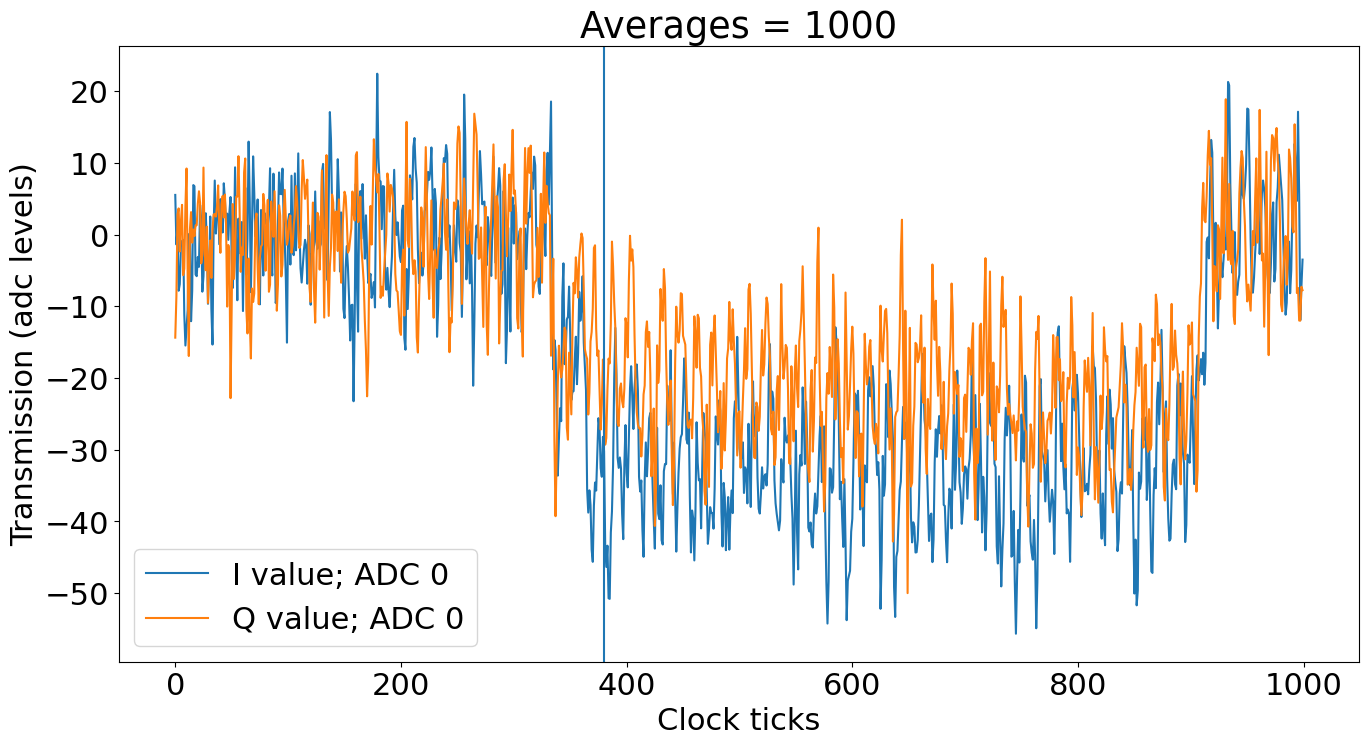

In [9]:
# Plot results.
subplot(111, title=f"Averages = {config['soft_avgs']}", xlabel="Clock ticks", ylabel="Transmission (adc levels)")
plot(adc1[0], label="I value; ADC 0")
plot(adc1[1], label="Q value; ADC 0")
#plot(adc2[0], label="I value; ADC 1")
#plot(adc2[1], label="Q value; ADC 1")
legend()

axvline(readout_cfg["adc_trig_offset"])
delta_adc=adc1[0]-adc1[1]
print("on peut estimer norme à ", (np.mean(adc1[0]))**2+np.mean(adc1[1])**2)

In [10]:
readout_cfg["adc_trig_offset"]=340 #Enter the value that best fits (in MHz)

# Single tone (Resonator) Spectroscopy

Measures the resonant frequency of the readout resonator when the qubit is in its ground state. We store this resonant frequency in the parameter <code> readout_cfg["f_res"] </code>.

In [11]:
class SingleToneSpectroscopyProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["frequency"], gen_ch=cfg["res_ch"])
        
        freq=self.freq2reg(cfg["frequency"], gen_ch=cfg["res_ch"], ro_ch=0)  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["res_gain"],
                                length=cfg["readout_length"])

        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))        

In [12]:
for job in client.jobs:
    try:
        job.cancel()
    except Exception:
        pass

In [13]:
expt_cfg={"reps":500, "relax_delay":10,
          "start":5925.0, "step":0.14, "expts":125
         }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

fpts=expt_cfg["start"] + expt_cfg["step"]*np.arange(expt_cfg["expts"])

jobs = {}

for f in tqdm(fpts):
    config["frequency"] = f

    nom = f"spectro_{f:.2f}MHz"

    jobs[f] = client.submit(
        prog=SingleToneSpectroscopyProgram,
        config=config,
        nom_programme=nom,
        acquire_method="acquire",
        display=False)
resultats = client.wait_all(refresh=0.2,display=False)
amps = []

for f in fpts:
    avgi, avgq = resultats[jobs[f]]
    amps.append(avgi[0][0] + 1j*avgq[0][0])
amps = np.array(amps)

100%|██████████| 125/125 [00:00<00:00, 1895.01it/s]


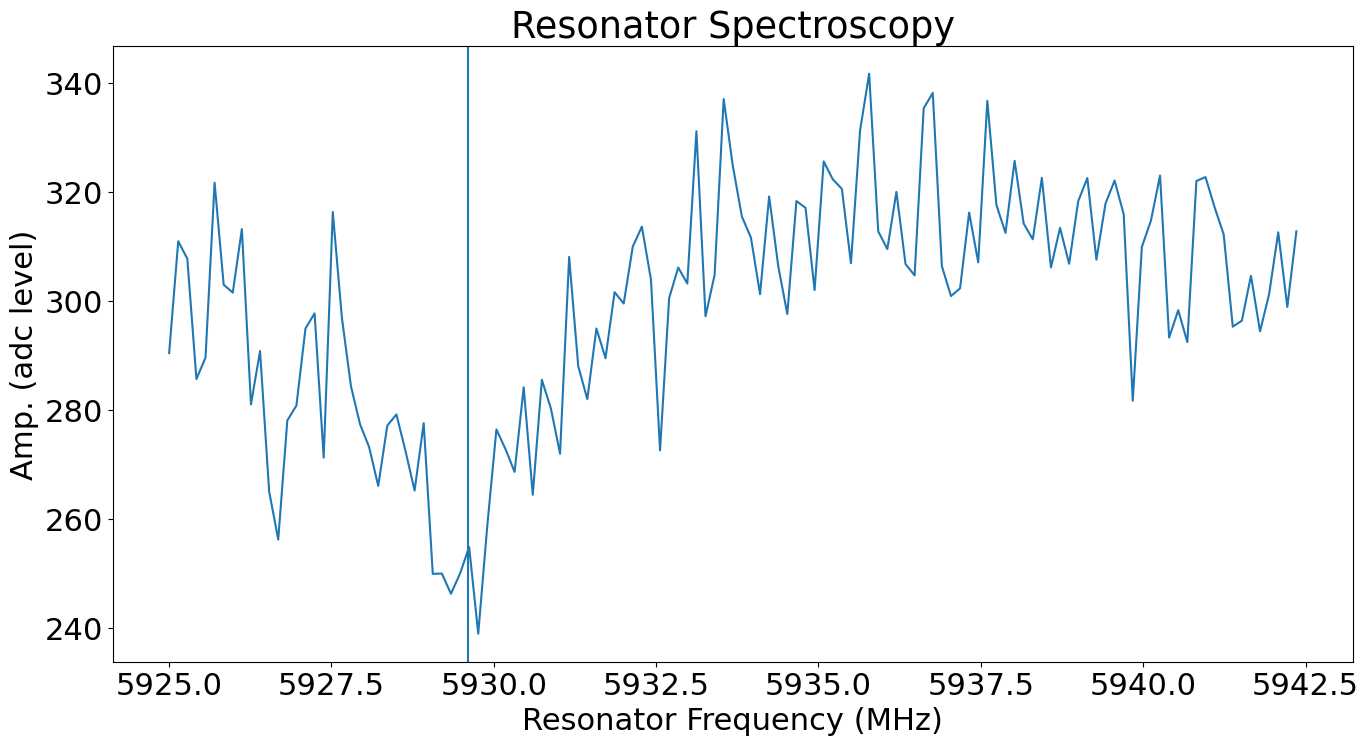

In [14]:
subplot(111,title="Resonator Spectroscopy", xlabel="Resonator Frequency (MHz)", ylabel="Amp. (adc level)")
plot(fpts,(amps.imag)**2+amps.real**2)
axvline(readout_cfg["f_res"])
show()

In [15]:
readout_cfg["f_res"]=5925.3 #Enter the value that best fits (in MHz)

# Pulse Probe (qubit) spectroscopy

Measures the qubit frequency f_ge. We store this parameter here: <code> qubit_cfg["f_ge"] </code>.

This program uses the RAveragerProgram class, which allows you to sweep a parameter directly on the processor rather than in a Python loop as in the above resonator spectroscopy example. Because the whole sweep is done on the processor there is less downtime (especially for fast experiments).

In [16]:
class PulseProbeSpectroscopyProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1) #JPA
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])

        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_freq=self.sreg(cfg["qubit_ch"], "freq")   # get frequency register for qubit_ch    
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"]) #conver f_jpa to dac

        self.f_start =self.freq2reg(cfg["start"], gen_ch=cfg["qubit_ch"])  # get start/step frequencies
        self.f_step =self.freq2reg(cfg["step"], gen_ch=cfg["qubit_ch"])

        # add qubit and readout pulses to respective channels
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="const", freq=self.f_start, phase=0, gain=cfg["qubit_gain"], 
                                 length=cfg["probe_length"])
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const", freq=f_jpa, phase=0, gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])
        self.sync_all(self.us2cycles(1))
    
    def body(self):
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05)) # align channels and wait 50ns
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)

        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))

    def update(self):
        self.mathi(self.q_rp, self.r_freq, self.r_freq, '+', self.f_step) # update frequency list index

In [17]:
expt_cfg={"start":3886.2, "step":0.03, "expts":300, "reps": 20,"rounds":5,
          "probe_length":soccfg.us2cycles(2.0, gen_ch=2), "qubit_gain":800
         }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

qspec = client.submit(prog=PulseProbeSpectroscopyProgram, 
                        config=config, nom_programme="Qubit spectro",acquire_method="acquire" )

expt_pts, avgi, avgq = qspec.wait()

Job 'Qubit spectro' ajouté à la file.
Qubit spectro terminé (16 s dont 16 s de mesure)


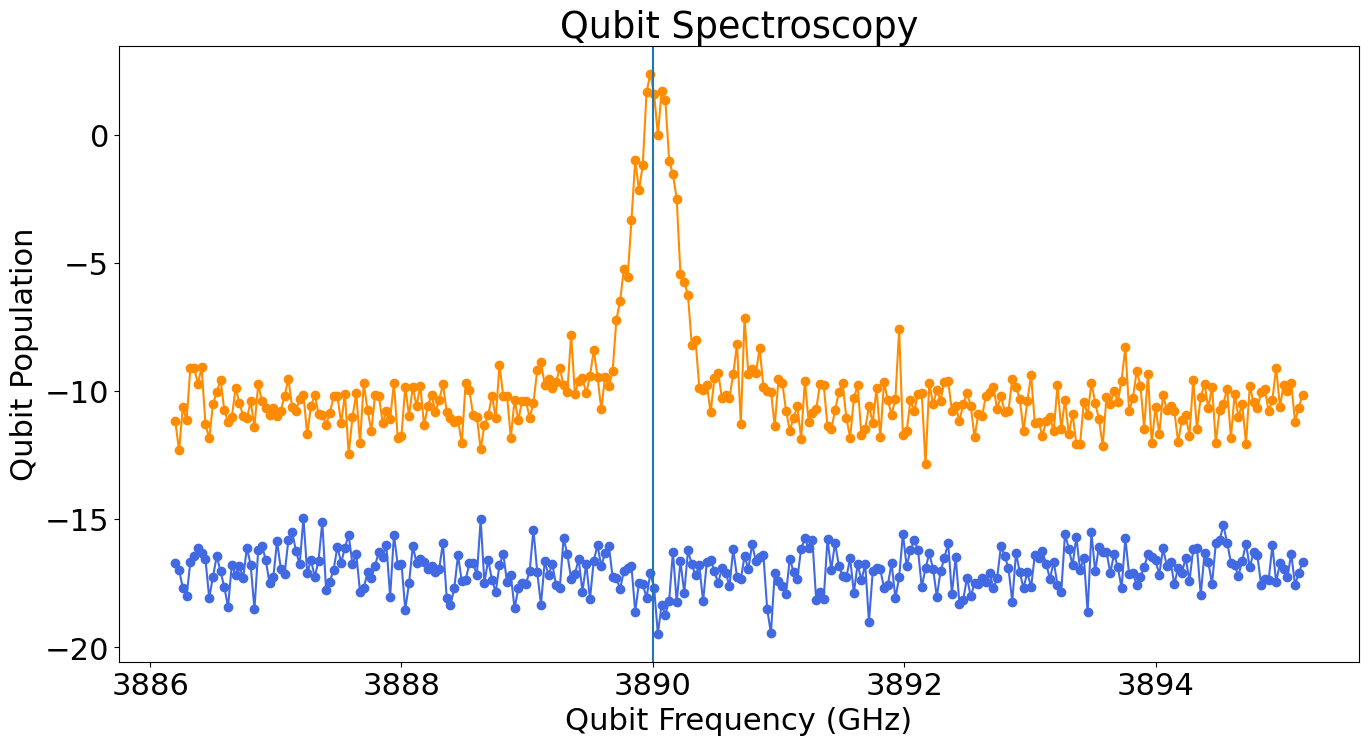

In [18]:
subplot(111,title="Qubit Spectroscopy", xlabel="Qubit Frequency (GHz)", ylabel="Qubit Population")
plot(expt_pts, avgi[0][0],'o-',color="royalblue")
plot(expt_pts, avgq[0][0],'o-',color="darkorange")
axvline(qubit_cfg["f_ge"]);

In [19]:
qubit_cfg["f_ge"]=3890.0 #Enter the value that best fits

# Length Rabi

Measures Rabi oscillations by sweeping over the duration of the qubit drive pulse. This is a preliminary measurement to prove that we see Rabi oscillations. This measurement is followed up by the Amplitude Rabi experiment below.

Note that we could speed up this measurement by using an RAveragerProgram (tProcessor loop over duration) instead of a AveragerProgram with a Python loop. We would need to update two registers, one for the pulse length and one for the sync after playing the pulse (sync_all automatically accounts for the pulse length if it's a fixed value, but that doesn't work if the pulse length is being modified by the tProcessor).

In [20]:
class LengthRabiProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg

        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1) #JPA
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"]) #conver f_jpa to dac
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])

        # add qubit and readout pulses to respective channels
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="const", freq=f_ge, phase=0, gain=cfg["qubit_gain"], 
                                 length=cfg["pulse_length"])
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const", freq=f_jpa, phase=0, gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])

        self.synci(200)
        
    def body(self):
        cfg=self.cfg
        self.pulse(ch=cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05)) # align channels and wait 50ns
        self.pulse(ch=self.cfg["jpa_ch"], t=0)

        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=cfg["res_ch"], 
             adcs=[0,1],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(cfg["relax_delay"]))

In [21]:
expt_cfg={
       "qubit_gain":8000,
        "start":4, "step":2, "expts":200, "reps": 400,
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]



jobs = {}

for length in tqdm(expt_pts):
    config["pulse_length"]=length

    nom = f"Rabi Oscillation, length={length:.2f}"

    jobs[length] = client.submit(prog=LengthRabiProgram, 
                        config=config, nom_programme=nom,acquire_method="acquire",display=False )
resultats = client.wait_all(refresh=0.2,display=False)
results = []

for length in expt_pts:
    avgi_rabi, avgq_rabi = resultats[jobs[length]]
    results.append(avgi_rabi[0][0] + 1j*avgq_rabi[0][0])
results = np.array(results)

100%|██████████| 200/200 [00:00<00:00, 2354.25it/s]


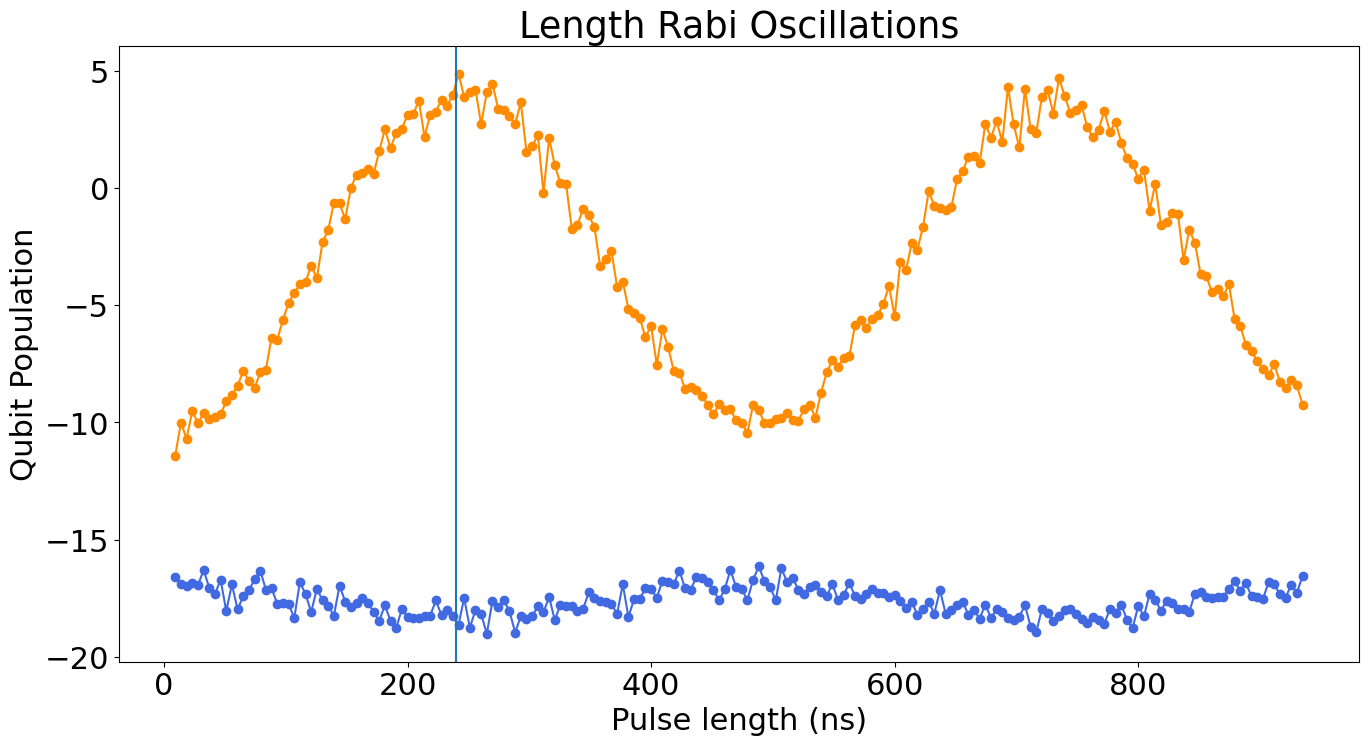

In [22]:
subplot(111, title="Length Rabi Oscillations", xlabel="Pulse length (ns)", ylabel="Qubit Population")
plot(soccfg.cycles2us(np.array(expt_pts), gen_ch=2)*1000,results.real,'o-',color="royalblue")
plot(soccfg.cycles2us(np.array(expt_pts), gen_ch=2)*1000,results.imag,'o-',color="darkorange");
axvline(240) #search for the right value yourself

# Amplitude Rabi

Measures Rabi oscillations by sweeping over the amplitude of the qubit drive pulse, which is an $\approx$ 100 ns ($\sigma$ $\approx$ 25 ns) long Gaussian pulse. We measure the $\pi$ and $\pi$/2 pulse amplitudes which are used in subsequent experiments to control the qubit. We store these parameters here: <code> qubit_cfg["pi_gain"] </code> and <code> qubit_cfg["pi2_gain"] </code>

In [23]:
class AmplitudeRabiProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_gain=self.sreg(cfg["qubit_ch"], "gain")   # get gain register for qubit_ch    
                
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1) #JPA
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"]) #conver f_jpa
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])

        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=self.deg2reg(90, gen_ch=cfg["qubit_ch"]), gain=cfg["start"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const", freq=f_jpa, phase=0, gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])
        
        self.sync_all(self.us2cycles(500))
    
    def body(self):
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05)) # align channels and wait 50ns

        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)
        
        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             t=self.cfg["jpa_pretrigger"],
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))
    
    def update(self):
        self.mathi(self.q_rp, self.r_gain, self.r_gain, '+', self.cfg["step"]) # update gain of the Gaussian pi pulse

In [24]:
expt_cfg={
        "start":0, "step":200, "expts":300, "reps": 400
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

rabi_ampl=client.submit(prog=AmplitudeRabiProgram, 
                        config=config, nom_programme="Amplitude Rabi Oscillation",acquire_method="acquire" )
x_pts, avgi_, avgq_  = rabi_ampl.wait()

Job 'Amplitude Rabi Oscillation' ajouté à la file.
Amplitude Rabi Oscillation terminé (60 s dont 60 s de mesure)


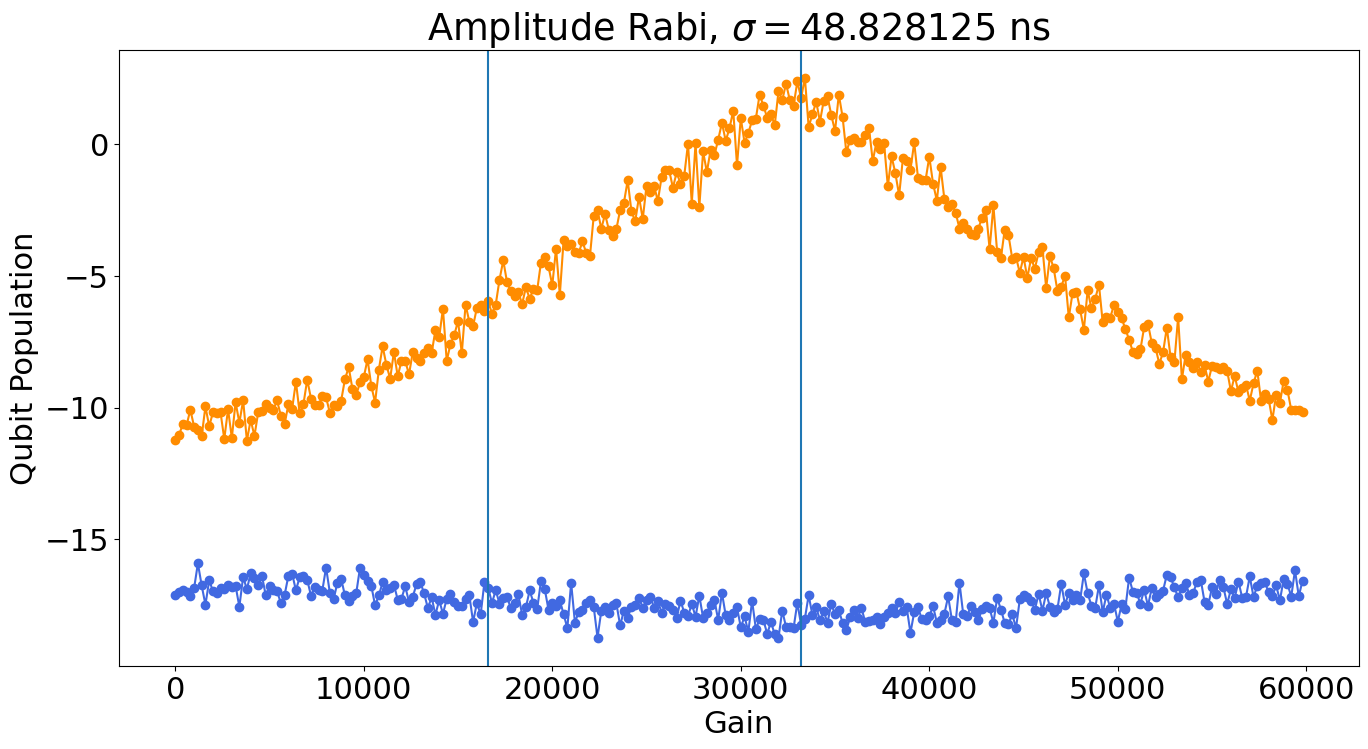

In [25]:
subplot(111, title= f"Amplitude Rabi, $\sigma={soccfg.cycles2us(config['sigma'], gen_ch=2)*1000}$ ns", xlabel="Gain", ylabel="Qubit Population" )
plot(x_pts,avgi_[0][0],'o-',color="royalblue")
plot(x_pts,avgq_[0][0],'o-',color="darkorange")

axvline(qubit_cfg["pi_gain"])
axvline(qubit_cfg["pi2_gain"]);

In [26]:
qubit_cfg["pi_gain"]=33000 #Enter the value that best fits
qubit_cfg["pi2_gain"]=qubit_cfg["pi_gain"]/2

# Single Shot

Measures the single shot readout fidelity of the system. We acquire single shot (I, Q) readout values by first preparing the qubit in its ground (blue dots) a certain number of times (in the below demo we take 5000 shots) and then preparing the qubit in its excited state (red dots) the same number of times. We then extract two parameters which are used to optimize the associated readout fidelity: the rotation angle of the IQ blobs and the threshold that classifies the two qubit states (ground and excited). We store theseA two parameters here <code> readout_cfg["res_phase"] </code> and <code> readout_cfg["threshold"] </code>.

Note that this experiment already assumes that you have found your qubit frequency and $\pi$ pulse amplitude. It is placed towards the top of this demo notebook because every time you reset the QICK firmware the single shot angle and threshold changes. So, this experiment is used to calibrate any experiment below that uses single shot data (such as the Active Reset experiment).

In [27]:
class SingleShotProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1)
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])

        cfg["start"]=0
        cfg["step"]=cfg["pi_gain"]
        cfg["reps"]=cfg["shots"]
        cfg["expts"]=2
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_gain=self.sreg(cfg["qubit_ch"], "gain")   # get frequency register for qubit_ch    
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"])
        
        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=0, gain=cfg["start"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])

        self.sync_all(self.us2cycles(500))
    
    def body(self):
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05)) # align channels and wait 50ns
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)

        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))
    
    def update(self):
        self.mathi(self.q_rp, self.r_gain, self.r_gain, '+', self.cfg["step"]) # update frequency list index
        
    def acquire(self,soc, progress=False):
        super().acquire(soc, progress=progress)
        return self.collect_shots()
        
    def collect_shots(self):
        shots_i0=self.di_buf[0].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_q0=self.dq_buf[0].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_i1=self.di_buf[1].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        shots_q1=self.dq_buf[1].reshape((self.cfg["expts"],self.cfg["reps"]))/self.cfg['readout_length']
        return shots_i0,shots_q0,shots_i1,shots_q1
        
    def analyze(self, shots_i, shots_q):
        plt.subplot(111, xlabel='I', ylabel='Q', title='Single Shot Histogram')
        plt.plot(shots_i[0],shots_q[0],'.',label='g')
        plt.plot(shots_i[1],shots_q[1],'.',label='e')
        plt.legend()
        plt.gca().set_aspect('equal', 'datalim')

Job 'Single Shot plots' ajouté à la file.
Single Shot plots terminé (5 s dont 5 s de mesure)
Optimal fidelity after rotation = 0.497


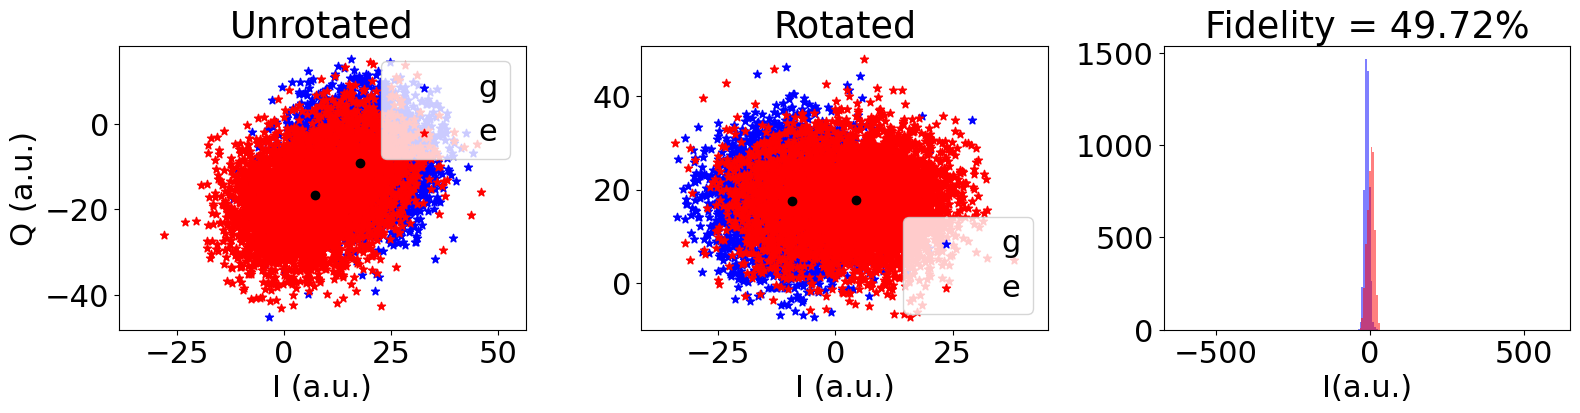

In [28]:
expt_cfg={
        "shots":5000, "res_phase":0
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

ssp=client.submit(prog=SingleShotProgram, 
                        config=config, nom_programme="Single Shot plots",acquire_method="acquire" )
di0, dq0, di1, dq1 = ssp.wait()

fid, threshold, angle,pts_g,pts_e = hist(data=[di0[0], dq0[0], di0[1], dq0[1]],  plot=True, ran=600,return_rot_data=True)
#print('Optimal fidelity after rotation = %.3f' % fid)
readout_cfg["res_phase"]=soccfg.deg2reg(-angle*180/pi, gen_ch=6) #sets the phase to rotate automatically in the following programs
readout_cfg["threshold"]=round(threshold)
print('Optimal fidelity after rotation = %.3f' % fid)

# Effective temperature

Here we compute the effective temperature according to the Boltzman law.

In [29]:
Ig_=pts_g[0]
P_0=len(Ig_[Ig_<readout_cfg["threshold"]])/len(Ig_)
P_1=1-P_0
T_eff= 6.62607015e-34*qubit_cfg["f_ge"]*1e6/1.380649e-23/np.log(P_0/P_1) #loi de Boltzman
print(f"La température effective du qubit est : {T_eff*1e3} mK")

La température effective du qubit est : 4166.502829401612 mK


# Same experiments with the threshold defined

Now that we have defined the threshold, we can normalize the y-axis of the previous experiments.

**Qubit spectroscopy after setting threshold**

Job 'Qubit spectro avec threshold' ajouté à la file.
Qubit spectro avec threshold terminé (16 s dont 16 s de mesure)


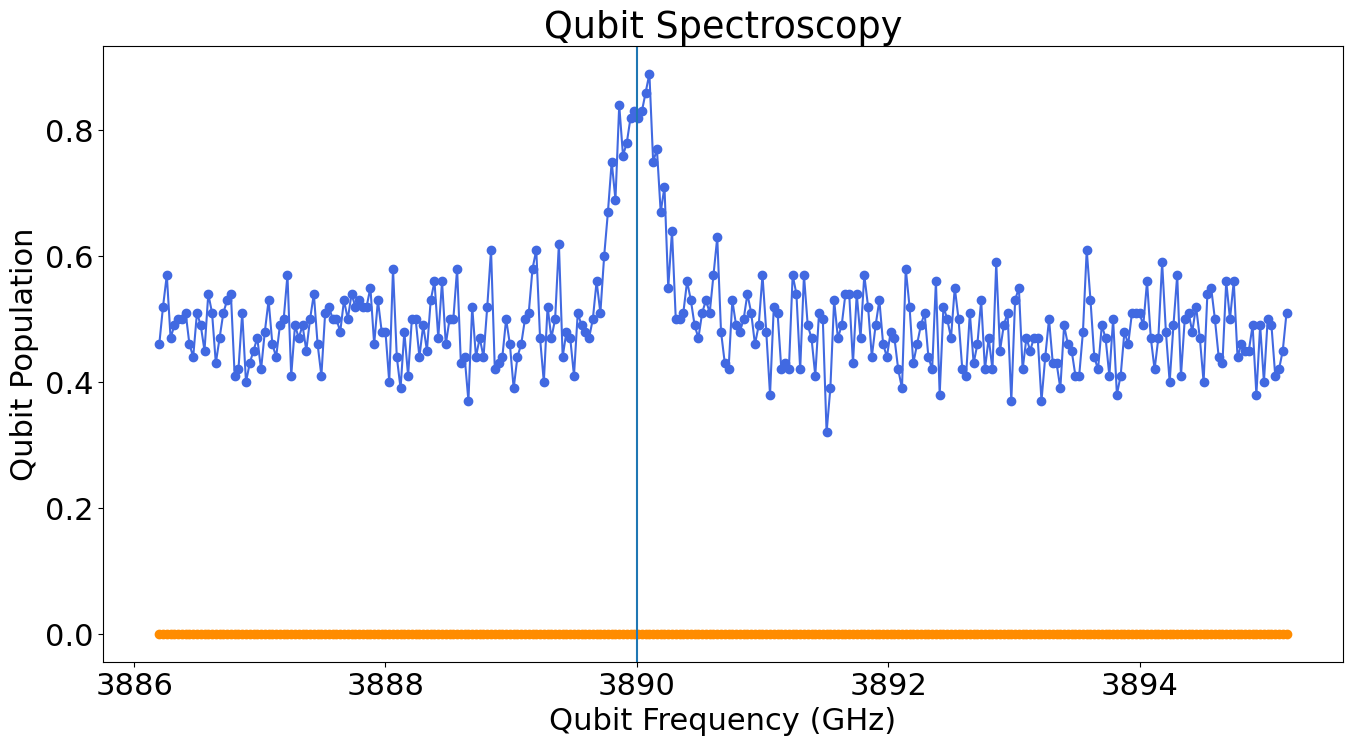

In [30]:
expt_cfg={"start":3886.2, "step":0.03, "expts":300, "reps": 20,"rounds":5,
          "probe_length":soccfg.us2cycles(2.0, gen_ch=2), "qubit_gain":800
         }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

qspec = client.submit(prog=PulseProbeSpectroscopyProgram, 
                        config=config, nom_programme="Qubit spectro avec threshold",acquire_method="acquire",threshold=readout_cfg["threshold"] )

expt_pts, avgi, avgq = qspec.wait()
subplot(111,title="Qubit Spectroscopy", xlabel="Qubit Frequency (GHz)", ylabel="Qubit Population")
plot(expt_pts, avgi[0][0],'o-',color="royalblue")
plot(expt_pts, avgq[0][0],'o-',color="darkorange")
axvline(qubit_cfg["f_ge"]);

**Length Rabi after setting threshold**

100%|██████████| 200/200 [00:00<00:00, 2382.26it/s]


-9


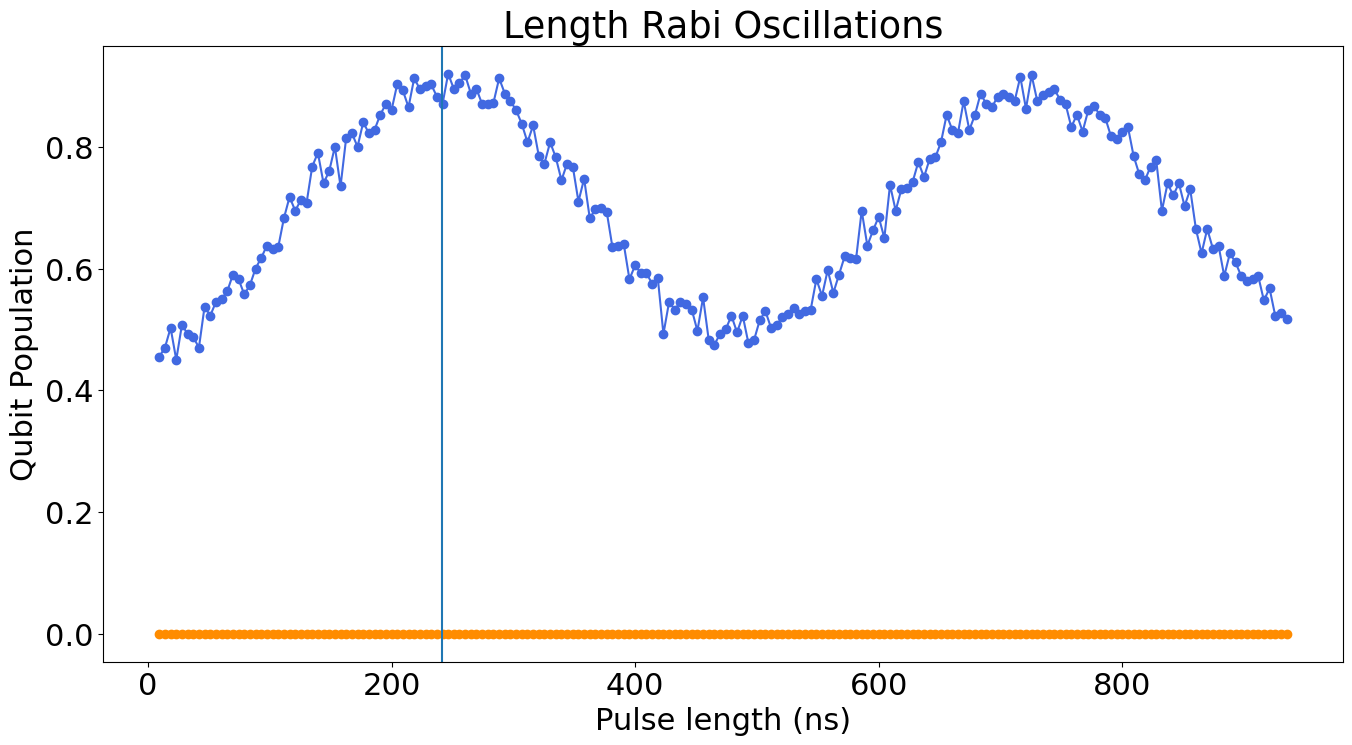

In [31]:
expt_cfg={
       "qubit_gain":8000,
        "start":4, "step":2, "expts":200, "reps": 400,
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs
expt_pts=[expt_cfg["start"] + ii*expt_cfg["step"] for ii in range(expt_cfg["expts"])]



jobs = {}

for length in tqdm(expt_pts):
    config["pulse_length"]=length

    nom = f"Rabi Oscillation, length={length:.2f}"

    jobs[length] = client.submit(prog=LengthRabiProgram, 
                        config=config, nom_programme=nom,acquire_method="acquire",threshold=readout_cfg["threshold"],display=False )
print(readout_cfg["threshold"])
resultats = client.wait_all(refresh=0.2,display=False)
results = []

for length in expt_pts:
    avgi, avgq = resultats[jobs[length]]
    results.append(avgi[0][0] + 1j*avgq[0][0])
results = np.array(results)
subplot(111, title="Length Rabi Oscillations", xlabel="Pulse length (ns)", ylabel="Qubit Population")
plot(soccfg.cycles2us(np.array(expt_pts), gen_ch=2)*1000,results.real,'o-',color="royalblue")
plot(soccfg.cycles2us(np.array(expt_pts), gen_ch=2)*1000,results.imag,'o-',color="darkorange");
axvline(241) #search for the right value yourself

**Amplitude Rabi after setting threshold**

Le nom 'Amplitude Rabi Oscillation' était déjà utilisé. Le job a été renommé en 'job_b3a0b5b5'.
job_b3a0b5b5 terminé (60 s dont 60 s de mesure)


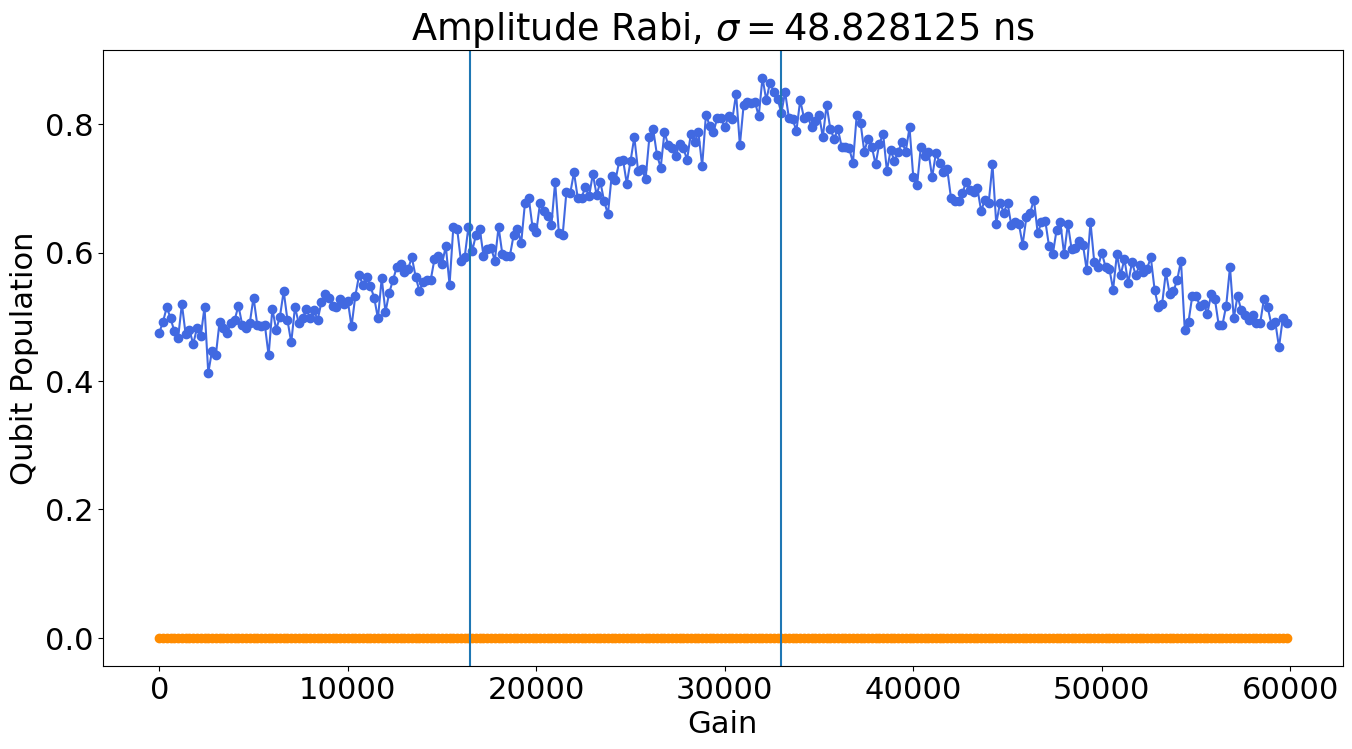

In [32]:
expt_cfg={
        "start":0, "step":200, "expts":300, "reps": 400
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

rabi_ampl=client.submit(prog=AmplitudeRabiProgram, 
                        config=config, nom_programme="Amplitude Rabi Oscillation",acquire_method="acquire", threshold=readout_cfg["threshold"])
x_pts, avgi_, avgq_  = rabi_ampl.wait()
subplot(111, title= f"Amplitude Rabi, $\sigma={soccfg.cycles2us(config['sigma'], gen_ch=2)*1000}$ ns", xlabel="Gain", ylabel="Qubit Population" )
plot(x_pts,avgi_[0][0],'o-',color="royalblue")
plot(x_pts,avgq_[0][0],'o-',color="darkorange")

axvline(qubit_cfg["pi_gain"])
axvline(qubit_cfg["pi2_gain"]);

# T1 Measure

In [33]:
class T1Program(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_wait = 3
        self.regwi(self.q_rp, self.r_wait, cfg["start"])
        print("initialize res_gain =", cfg["res_gain"])
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1)
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"])

        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=0, gain=cfg["pi_gain"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])

        self.sync_all(self.us2cycles(500))
    
    def body(self):
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all()
        self.sync(self.q_rp,self.r_wait)
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)

        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))
    
    def update(self):
        self.mathi(self.q_rp, self.r_wait, self.r_wait, '+', self.us2cycles(self.cfg["step"])) # update frequency list index

In [34]:
expt_cfg={ "start":0, "step":0.25, "expts":400, "reps": 200,
        "relax_delay":750
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs
t1p=client.submit(prog=T1Program, 
                        config=config, nom_programme="T1 Measure",acquire_method="acquire", threshold=readout_cfg["threshold"])
x_pts, avgi, avgq = t1p.wait()

Job 'T1 Measure' ajouté à la file.
T1 Measure terminé (65 s dont 65 s de mesure)


In [45]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# données
t = np.array(x_pts)
y = np.array(avgi[0][0])

# modèle T1
def T1_model(t, A, T1, B):
    return A*np.exp(-t/T1) + B

# estimation initiale
A0 = y.max() - y.min()
T10 = (t.max() - t.min())/5
B0 = y.min()

p0 = [A0, T10, B0]

# fit
popt, pcov = curve_fit(
    T1_model,
    t,
    y,
    p0=p0
)

A_fit, T1_fit, B_fit = popt

# erreur statistique
dA, dT1, dB = np.sqrt(np.diag(pcov))

print(f"T1 = {T1_fit:.3f} ± {dT1:.3f} µs")

# courbe ajustée
tfit = np.linspace(t.min(), t.max(), 1000)

plt.figure(figsize=(8,5))
plt.plot(t, y, 'o', label='Data')
plt.plot(
    tfit,
    T1_model(tfit, *popt),
    '-',
    label=f'T1 = {T1_fit:.2f} ± {dT1:.2f} µs'
)

plt.xlabel("Time (µs)")
plt.ylabel("Qubit Population")
#plt.title("T1 Experiment")
plt.legend()
plt.grid()
plt.show()

FileNotFoundError: Could not find module 'C:\Users\NS2-manip\AppData\Local\miniforge3\envs\new_qick\lib\site-packages\scipy\.libs\libbanded5x.4HQRZL2D6UUGPVKYP75OJIKUJ77H7S4U.gfortran-win_amd64.dll' (or one of its dependencies). Try using the full path with constructor syntax.

The following code block is unnecessary if you have the scipy module

In [ ]:
import matplotlib.pyplot as plt
def T1_model(t, A, T1, B):
    return A*np.exp(-t/T1) + B
t = np.array(x_pts)
y = np.array(avgi[0][0])
y_modele = T1_model(t, y[0]-0.08, 25, 0.08)
plt.figure()
plt.plot(t, y, 'o', label='Data')
plt.plot(t, y_modele, 'o', label='Data')
plt.xlabel("Time (µs)")
plt.ylabel("Qubit Population")
plt.title("T1 Experiment")
plt.legend()
plt.grid()
plt.show()

# Ramsey Fringe Experiment

Measures the qubit T2 Ramsey characteristic decay time by preparing the qubit in a superposition state with a  $\frac{\pi}{2}$ pulse followed by a variable delay ($\tau$) before applying another $\frac{\pi}{2}$ pulse with a phase advanced by $\Delta \phi = \omega * \tau$, where $\omega$ is the Ramsey frequency. This exponential decay envelope can be fitted in post-processing to obtain the qubit T2 Ramsey time.

In [ ]:
class RamseyProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_wait = 3
        self.r_phase2 = 4
        self.r_phase=self.sreg(cfg["qubit_ch"], "phase")
        self.regwi(self.q_rp, self.r_wait, cfg["start"])
        self.regwi(self.q_rp, self.r_phase2, 0)
        
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1)
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"])

        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=0, gain=cfg["pi2_gain"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])     
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])
        
        self.sync_all(self.us2cycles(0.2))
    
    def body(self):
        self.regwi(self.q_rp, self.r_phase, 0)
        
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.mathi(self.q_rp, self.r_phase, self.r_phase2,"+",0)
        self.sync_all()
        self.sync(self.q_rp,self.r_wait)

        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05))
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)

        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
                     t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))
        
    def update(self):
        self.mathi(self.q_rp, self.r_wait, self.r_wait, '+', self.cfg["step"]) # update the time between two π/2 pulses
        self.mathi(self.q_rp, self.r_phase2, self.r_phase2, '+', self.cfg["phase_step"]) # advance the phase of the LO for the second π/2 pulse

In [ ]:
expt_cfg={"start":soccfg.us2cycles(0.0), "step":soccfg.us2cycles(1/50),
          "phase_step": soccfg.deg2reg(2*360/100, gen_ch=0), "expts":500,"reps": 20, "rounds": 20
       }#phase step => f_drive = f_qubit sans pb ? #
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs
t2p=client.submit(prog=RamseyProgram, 
                        config=config, nom_programme="Ramsey Fringe Experiment",acquire_method="acquire", threshold=readout_cfg["threshold"])
x_pts, avgi, avgq = t1p.wait()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

t = soccfg.cycles2us(x_pts)
y = np.array(avgi[0][0])
f=soccfg.reg2deg (config["phase_step"], gen_ch=config["qubit_ch"])/soccfg.cycles2us(config["step"]) /360 
f+=-0.024
def ramsey_model(t,A,B,T2,phi):
    return A+B*np.exp(-t/T2)*np.cos(2*np.pi*f*t+phi)

# estimations initiales
A0 = np.mean(y)
B0 = (y.max()-y.min())/2
T20 = t.max()/2


phi0 = 0

p0 = [A0,B0,T20,phi0]

popt, pcov = curve_fit(
    ramsey_model,
    t,
    y,
    p0=p0,
    maxfev=10000
)

A,B,T2,phi = popt
print(f"T2* = {T2:.2f} µs")
print(f"Ramsey frequency = {f:.4f} MHz")
print

tfit = np.linspace(t.min(), t.max(), 5000)

plt.figure(figsize=(8,5))
plt.plot(t,y,'o',label='Data')
plt.plot(tfit,
         ramsey_model(tfit,*popt),
         '-',
         label=f"T2*={T2:.2f} µs")
title="Ramsey Fringe Experiment"
plt.xlabel("Delay (µs)")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

# franges de ramsey (echo version)

This program is similar to the Ramsey fringe experiment but here we put a $\pi$ pulse after waiting $\tau$.

In [ ]:
class RamseyEchoProgram(RAveragerProgram):
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_wait = 3
        self.r_phase2 = 4
        self.r_phase=self.sreg(cfg["qubit_ch"], "phase")
        self.r_gain = self.sreg(cfg["qubit_ch"], "gain") #ajouté mour madif le gain
        self.regwi(self.q_rp, self.r_wait, cfg["start"])
        self.regwi(self.q_rp, self.r_phase2, 0)
        
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1)
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"])

        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=0, gain=cfg["pi2_gain"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])    
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])
            
        
        self.sync_all(self.us2cycles(0.2))
    
    def body(self):
        cfg = self.cfg
        self.regwi(self.q_rp, self.r_phase, 0)
        
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse

        self.sync(self.q_rp,self.r_wait) #tau/2 après modifs
        
        
        #ajout pulse pi
        self.regwi(
            self.q_rp,
            self.r_gain,
            cfg["pi_gain"])
        self.pulse(ch=self.cfg["qubit_ch"]) #pulse pi normaleemnt
        self.regwi(
            self.q_rp,
            self.r_gain,
            self.cfg["pi2_gain"]) #pour que le prochain oulse soit pi/2
        self.sync(self.q_rp,self.r_wait) #re wait de tau/2

        self.mathi(self.q_rp, self.r_phase, self.r_phase2,"+",0)        
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05))
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)
        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))
        
    def update(self): #ajouté un //2 pour ce programme dans le step au niveau de config 
        self.mathi(self.q_rp, self.r_wait, self.r_wait, '+', self.cfg["step"]) # update the time between two π/2 pulses
        self.mathi(self.q_rp, self.r_phase2, self.r_phase2, '+', self.cfg["phase_step"]) # advance the phase of the LO for the second π/2 pulse

In [ ]:
expt_cfg_echo={"start":soccfg.us2cycles(0.0), "step":soccfg.us2cycles(1/50/2),
          "phase_step": soccfg.deg2reg(2*360/100, gen_ch=hw_cfg["qubit_ch"]), "expts":500,"reps": 20, "rounds": 20
       }#phase step => f_drive = f_qubit sans pb ? 
config_echo={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg_echo} #combine configs

t2p_echo=client.submit(prog=RamseyEchoProgram, config=config_echo,nom_programme="Ramsey Fringe Experiment (echo version)",
                      acquire_method="acquire", threshold=readout_cfg["threshold"])
x_pts_echo, avgi_echo, avgq_echo= t2p_echo.wait()

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

t = 2*soccfg.cycles2us(x_pts_echo) #car on a pris tau/2
y = np.array(avgi_echo[0][0])
f=soccfg.reg2deg (config_echo["phase_step"], gen_ch=config_echo["qubit_ch"])/soccfg.cycles2us(config_echo["step"]) /360 /2

def ramsey_echo_model(t, A, B, T2, phi):
        return A+B*np.exp(-t/T2)*np.cos(2*np.pi*f*t+phi)

# estimations initiales
A0 = np.mean(y)
B0 = (y.max()-y.min())/2
T20 = t.max()/2

# fréquence estimée à la main

phi0 = 0

p0 = [A0,B0,T20,phi0]

popt, pcov = curve_fit(
    ramsey_echo_model,
    t,
    y,
    p0=p0,
    maxfev=10000
)

A,B,T2,phi = popt

print(f"T2_echo = {T2:.2f} µs")
print(f"Ramsey frequency = {f:.4f} MHz")

tfit = np.linspace(t.min(), t.max(), 5000)

plt.figure(figsize=(8,5))
plt.plot(t,y,'o',label='Data')
plt.plot(tfit,
         ramsey_echo_model(tfit,*popt),
         '-',
         label=f"T2_echo={T2:.2f} µs")
plt.title="Ramsey Echo Fringe Experiment"
plt.xlabel("Delay (µs)")
plt.ylabel("Population")
plt.legend()
plt.grid()
plt.show()

# Active reset

This experiment demonstrates active reset with the QICK. 

The protocol is as follows: there is an overall loop over the qubit drive pulse amplitude (as in the amplitude Rabi measurement above). During each loop iteration, several measurements occur. First, an amplitude rabi measurement is done (labeled "pre-reset" in the below plot). If that measurement doesn't exceed a threshold (meaning that the qubit is in its ground state after the qubit drive pulse was applied) nothing is done. But if the measurement exceeds the threshold (meaning that the the qubit is in its excited state after the qubit drive pulse was applied) a $\pi$ pulse is applied to the qubit (hopefully bringing it back to the gnd state). Finally, a second measurement is done (labeled "post-reset" in the below plot). 

Note that to run this experiment you must first successfully calibrate the single-shot readout threshold using the Single Shot experiment above. 

In [46]:
class ActiveResetProgram(RAveragerProgram):        
    def initialize(self):
        cfg=self.cfg
        
        self.q_rp=self.ch_page(self.cfg["qubit_ch"])     # get register page for qubit_ch
        self.r_gain=self.sreg(cfg["qubit_ch"], "gain")   # get frequency register for qubit_ch  
        
        self.r_gain2=4
        self.regwi(self.q_rp, self.r_gain2, cfg["start"])        

        self.r_thresh = 6
        self.regwi(0,self.r_thresh,cfg["threshold"]*cfg["readout_length"])
        
        self.declare_gen(ch=cfg["res_ch"], nqz=1) #Readout
        self.declare_gen(ch=cfg["qubit_ch"], nqz=2) #Qubit
        self.declare_gen(ch=cfg["jpa_ch"], nqz=1)
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["f_res"], gen_ch=cfg["res_ch"])
        
        f_res=self.freq2reg(cfg["f_res"], gen_ch=cfg["res_ch"], ro_ch=0) # conver f_res to dac register value
        f_ge=self.freq2reg(cfg["f_ge"], gen_ch=cfg["qubit_ch"])
        f_jpa = self.freq2reg(cfg["jpa_freq"], gen_ch=cfg["jpa_ch"])

        # add qubit and readout pulses to respective channels
        self.add_gauss(ch=cfg["qubit_ch"], name="qubit", sigma=cfg["sigma"], length=cfg["sigma"]*4)
        self.set_pulse_registers(ch=cfg["qubit_ch"], style="arb", freq=f_ge, phase=0, gain=cfg["start"], 
                                 waveform="qubit")
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=f_res, phase=cfg["res_phase"], gain=cfg["res_gain"], 
                                 length=cfg["readout_length"])      
        self.set_pulse_registers(ch=cfg["jpa_ch"],style="const",freq=f_jpa,phase=0,gain=cfg["jpa_gain"],
                                 length=cfg["jpa_length"])  
        
        self.sync_all(self.us2cycles(500))
    
    def body(self):
        self.mathi(self.q_rp,self.r_gain,self.r_gain2,"+",0)
        
        self.pulse(ch=self.cfg["qubit_ch"])  #play probe pulse
        self.sync_all(self.us2cycles(0.05))
        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)
        
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             t=self.cfg["jpa_pretrigger"],
             adc_trig_offset=self.cfg["adc_trig_offset"])
        
        self.wait_all(200) # pause until 200 clocks past the end of the readout window
        self.read(0,0,"lower",2)
        self.read(0,0,"upper",3)
        self.condj(0,2,'<',self.r_thresh,'after_reset')

        self.regwi(self.q_rp, self.r_gain, self.cfg["pi_gain"])  #pi pulse qubit
        self.pulse(ch=self.cfg["qubit_ch"], t=0)

        self.label('after_reset')
        self.sync_all(self.us2cycles(1)) # align channels and wait 50ns

        
        self.pulse(ch=self.cfg["jpa_ch"], t=0)
        #trigger measurement, play measurement pulse, wait for qubit to relax
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             t=self.cfg["jpa_pretrigger"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))

    def update(self):
        self.mathi(self.q_rp, self.r_gain2, self.r_gain2, '+', self.cfg["step"]) # update frequency list index
        

Job 'Active Reset' ajouté à la file.
Active Reset terminé (62 s dont 62 s de mesure)


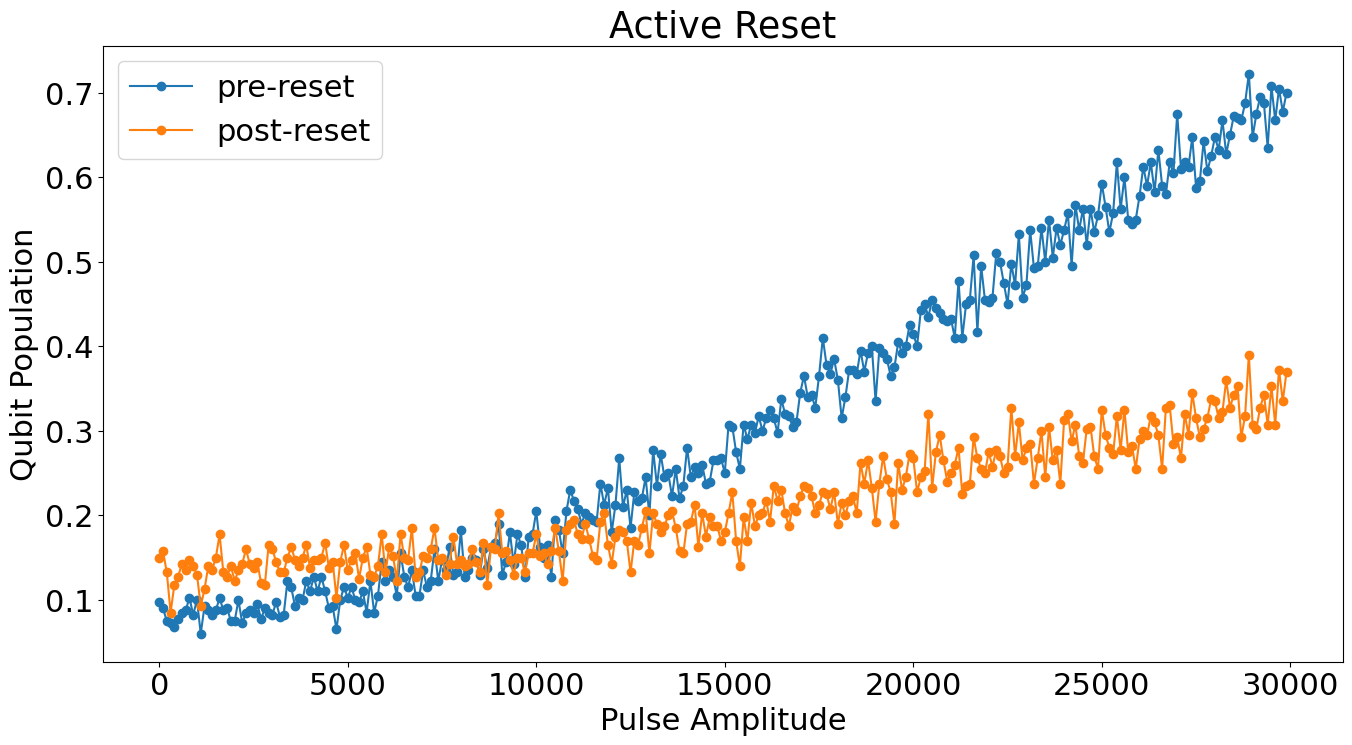

In [47]:
expt_cfg={
        "start":0, "step":100, "expts":300, "reps": 400 
       }
config={**hw_cfg,**readout_cfg,**qubit_cfg,**expt_cfg} #combine configs

areset=client.submit(prog=ActiveResetProgram, config=config,nom_programme="Active Reset",
                      acquire_method="acquire", threshold=readout_cfg["threshold"])
expt_pts,avgi,avgq= areset.wait()

subplot(111,title="Active Reset", xlabel="Pulse Amplitude", ylabel="Qubit Population")
plot(expt_pts,avgi[0][0],'o-', label="pre-reset")
plot(expt_pts,avgi[0][1], 'o-', label="post-reset")
legend();